# Домашняя работа 1


## Описание

В этой домашней работе вы должны применить знания по многослойным нейроным сетям 

- Для простоты попробуем обучить сначала однослойный перцептрон
- Решать будем простую задачу бинарной классификации
- Датасет игрушечный -  `load_data()` загружает его


In [1]:
import numpy as np
import torch
from torch import nn
import torch.optim as optim
import sklearn
from sklearn.datasets import make_gaussian_quantiles
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import tqdm
import copy

## Загрузка данных

In [2]:
def load_data(n_samples=500):
    return make_gaussian_quantiles(
        mean=None,
        cov=0.7,
        n_samples=n_samples,
        n_features=2,
        n_classes=2,
        shuffle=True,
        random_state=42,
    )

In [3]:
gaussian_quantiles = load_data()
X, y = gaussian_quantiles

print(X[:10, :])
print(y[:10])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

[[-1.13773727  0.62436053]
 [-0.75970745 -1.18161805]
 [-0.82471758  0.42171557]
 [-0.09398039 -0.18487643]
 [-0.80731289  0.57399183]
 [ 0.67980788  1.13471182]
 [-1.70521733 -0.84342552]
 [ 1.57461467  1.12565917]
 [-0.22579357 -0.81889248]
 [ 0.97317262  0.00856159]]
[1 1 0 0 1 1 1 1 0 1]


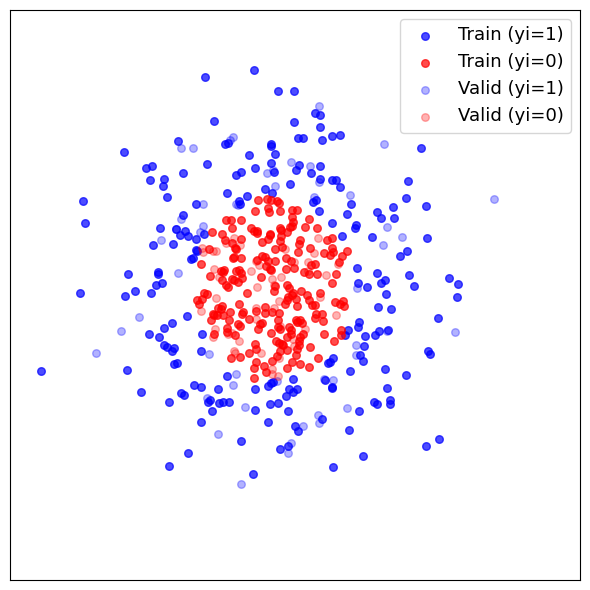

In [4]:
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])

def plot_data(X, y, xy_labels=True, label=None, **kwargs):
    X_1 = X[y == 1]
    X_0 = X[y == 0]
    if label is not None:
        plt.scatter(X_1[:, 0], X_1[:, 1], c="blue", s=30, label=label + " (yi=1)", **kwargs)
        plt.scatter(X_0[:, 0], X_0[:, 1], c="red", s=30, label=label + " (yi=0)", **kwargs)
    plt.xticks(())
    plt.yticks(())
    plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

plt.figure(figsize=(6, 6))
plot_data(X_train, y_train, alpha=0.7, label="Train")
plot_data(X_test, y_test, alpha=0.3, label="Valid")
plt.legend(fontsize=13)
plt.tight_layout()

In [5]:
X_train

array([[ 5.23470860e-01, -7.17149464e-01],
       [-1.32518818e+00,  6.36208546e-01],
       [ 1.20585575e+00, -1.20132847e+00],
       [-5.12695802e-01, -3.24374397e-01],
       [ 1.16540817e-02, -2.01844960e-02],
       [-1.03490721e+00, -1.10477326e+00],
       [ 1.36259753e+00, -1.15467572e+00],
       [-5.22760728e-01,  2.18293388e-02],
       [-1.02250549e+00,  5.96537286e-01],
       [-9.62990317e-01,  3.14331514e-01],
       [-2.86713012e-01, -3.10769725e-01],
       [-3.73581212e-01,  7.16514638e-01],
       [ 6.61824810e-01, -7.60848132e-01],
       [ 6.25230687e-01,  5.10672402e-01],
       [ 1.52160226e-01,  2.07676242e-01],
       [ 2.17433546e-01,  6.54119945e-01],
       [-3.63525625e-01, -2.58671957e-01],
       [ 5.70511352e-01,  1.54506620e+00],
       [-5.98466020e-01,  5.68592271e-01],
       [ 1.79375232e+00,  5.30374706e-01],
       [ 5.41895109e-01,  1.27425820e+00],
       [ 7.67725737e-02, -1.66291946e+00],
       [-3.73303843e-01, -1.58090320e+00],
       [-1.

## Класс нейросети

Вам необходимо описать простую полносвязную многослойную нейронную сеть 

In [6]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 10)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(10, 12)
        self.act2 = nn.LeakyReLU()
        self.layer3 = nn.Linear(12, 6)
        self.act3 = nn.LeakyReLU()
        self.layer4 = nn.Linear(6, 1)
        self.sig = nn.Sigmoid()
                        
    def forward(self, X):
        X = self.act1(self.layer1(X))
        X = self.act2(self.layer2(X))
        X = self.act3(self.layer3(X))
        X = self.sig(self.layer4(X))
        return X 
    

##  Функция обучения сети

In [7]:
def train(model, loss_function, opt, 
          n_epochs, batch_size, lr,
          X_train, y_train, X_val=None, y_val=None):
    
    #convert dataset to tensor
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size)
    
    batch_start = torch.arange(0, len(X_train), batch_size)
    opt = opt(model.parameters(), lr=lr)
    
    # Hold the best model
    best_acc = - np.inf   # init to negative infinity
    best_weights = None
    preds_history = []
    loss_history = [] #took from seminar-3
    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=False) as bar:
            bar.set_description(f"Epoch {epoch}")
            for start in bar:
                # take a batch
                X_batch = X_train[start:start+batch_size]
                y_batch = y_train[start:start+batch_size]
                # forward
                y_pred = model(X_batch)
                loss = loss_function(y_pred, y_batch.reshape(batch_size, 1))
                loss_history.append(loss.item())
                # backward pass
                
                opt.zero_grad() # makes gradients equal zero
                loss.backward() # backpropagation
                
                # update weights

                opt.step() # update model parametres

                # print progress
                acc = (y_pred.round() == y_batch.reshape(batch_size, 1)).float().mean()
                bar.set_postfix(
                    loss=float(loss),
                    acc=float(acc)
                )
        # evaluate accuracy at end of each epoch
        if X_val is not None and y_val is not None:
            model.eval()
            y_pred = model(X_val).flatten()
            acc = (y_pred.round() == y_val).float().mean()
            acc = float(acc)
            if acc > best_acc:
                best_acc = acc
                best_weights = copy.deepcopy(model.state_dict())
            if acc > 0.98:
                break
    # restore model and return best accuracy
    
    
    model.load_state_dict(best_weights)
    
    return loss_history, best_acc

### Обучите сеть

Обучите сеть три раза - с тремя разными оптимизиторами
Не забудьте переинициализировать сеть заного перед каждой загрузкой. Убедитесь, что вы верно передали параметры сети в оптимизатор

**Подсказка** Лучше объявить три независимых объекта - модель1, модель2 и модель3

In [8]:
X_train_torch = torch.from_numpy(X_train).float()
y_train_torch = torch.from_numpy(y_train).float()
X_valid_torch = torch.from_numpy(X_test).float()
y_valid_torch = torch.from_numpy(y_test).float()


model_sgd = NeuralNetwork()
model_adam = NeuralNetwork()
model_rmsprob = NeuralNetwork()

optims = {'SGD': torch.optim.SGD, # use SGD
          'Adam': torch.optim.Adam, # use Adam
          'RMSProp': torch.optim.RMSprop # use RMSProp
}

loss_history = {}

epochs_dict = {'SGD': 100, 'Adam': 20, 'RMSProp': 20}

if 'SGD' in optims:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_sgd, nn.BCELoss(), opt, n_epochs, 20, 0.1, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)

elif 'Adam' in optims:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_adam, nn.BCELoss(), opt, n_epochs, 20, 0.1, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)        
        
        
else:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_rmsprob, nn.BCELoss(), opt, n_epochs, 20, 0.01, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)
        
        

Epoch 12: 100%|█████████████████████████████████████████████████| 20/20 [00:00<00:00, 317.78batch/s, acc=1, loss=0.192]


SGD: 0.9800000190734863


Epoch 12: 100%|█████████████████████████████████████████████████| 20/20 [00:00<00:00, 266.94batch/s, acc=1, loss=0.012]


Adam: 0.9800000190734863


Epoch 19: 100%|███████████████████████████████████████████████| 20/20 [00:00<00:00, 290.15batch/s, acc=0.45, loss=46.1]

RMSProp: 0.49000000953674316


### А теперь посмотрим на графики лоссов

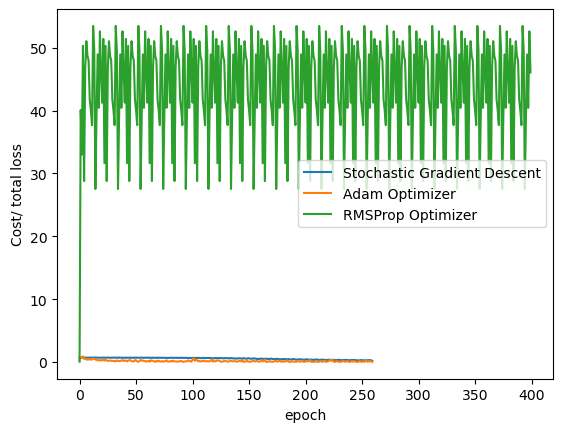

In [9]:
loss_SGD = loss_history["SGD"]
loss_Adam = loss_history["Adam"]
loss_rmsprop = loss_history["RMSProp"]


plt.plot(loss_SGD, label = "Stochastic Gradient Descent")
plt.plot(loss_Adam, label = "Adam Optimizer")
plt.plot(loss_rmsprop, label = 'RMSProp Optimizer')
plt.xlabel('epoch')
plt.ylabel('Cost/ total loss')
plt.legend()
plt.show()

### Инициализация

Теперь проинициализируйте веса в вашей модели: случайно и Ксавьером. Сравните результат

# Обнулим сначала веса

In [10]:
class RandomNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 10)
        nn.init.normal_(self.layer1.weight, mean=0, std=1)
        nn.init.normal_(self.layer1.bias, mean=0, std=1)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(10, 12)
        self.act2 = nn.LeakyReLU()
        self.layer3 = nn.Linear(12, 6)
        self.act3 = nn.LeakyReLU()
        self.layer4 = nn.Linear(6, 1)
        self.sig = nn.Sigmoid()
                        
    def forward(self, X):
        X = self.act1(self.layer1(X))
        X = self.act2(self.layer2(X))
        X = self.act3(self.layer3(X))
        X = self.sig(self.layer4(X))
        return X 

    


In [11]:
X_train_torch = torch.from_numpy(X_train).float()
y_train_torch = torch.from_numpy(y_train).float()
X_valid_torch = torch.from_numpy(X_test).float()
y_valid_torch = torch.from_numpy(y_test).float()

model_sgd = RandomNeuralNetwork()
model_adam = RandomNeuralNetwork()
model_rmsprob = RandomNeuralNetwork()

optims = {'SGD': torch.optim.SGD, # use SGD
          'Adam': torch.optim.Adam, # use Adam
          'RMSProp': torch.optim.RMSprop # use RMSProp
}

loss_history = {}

epochs_dict = {'SGD': 100, 'Adam': 20, 'RMSProp': 20}

if 'SGD' in optims:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_sgd, nn.BCELoss(), opt, n_epochs, 20, 0.1, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)

elif 'Adam' in optims:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_adam, nn.BCELoss(), opt, n_epochs, 20, 0.1, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)        
        
        
else:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_rmsprob, nn.BCELoss(), opt, n_epochs, 20, 0.01, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)
        

Epoch 99: 100%|███████████████████████████████████████████████| 20/20 [00:00<00:00, 281.98batch/s, acc=1, loss=0.00162]


SGD: 0.9599999785423279


Epoch 16: 100%|████████████████████████████████████████████████| 20/20 [00:00<00:00, 294.42batch/s, acc=1, loss=0.0412]


Adam: 0.9800000190734863


Epoch 19: 100%|█████████████████████████████████████████████████| 20/20 [00:00<00:00, 322.91batch/s, acc=0.45, loss=55]

RMSProp: 0.49000000953674316


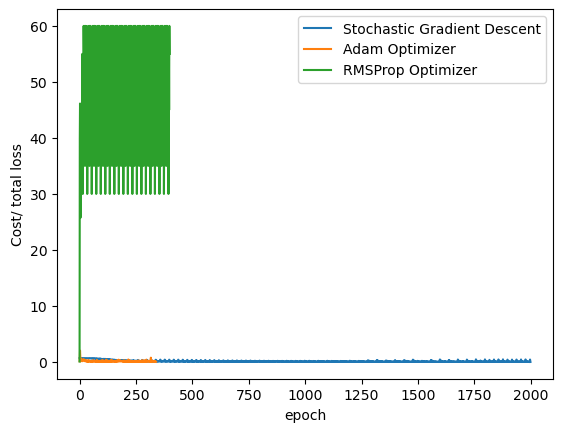

In [12]:
loss_SGD = loss_history["SGD"]
loss_Adam = loss_history["Adam"]
loss_rmsprop = loss_history["RMSProp"]


plt.plot(loss_SGD, label = "Stochastic Gradient Descent")
plt.plot(loss_Adam, label = "Adam Optimizer")
plt.plot(loss_rmsprop, label = 'RMSProp Optimizer')
plt.xlabel('epoch')
plt.ylabel('Cost/ total loss')
plt.legend()
plt.show()

# Расставим веса в нейронах по Ксавьеру

In [13]:
class XavierNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 10)
        nn.init.xavier_normal_(self.layer1.weight)
        nn.init.zeros_(self.layer1.bias)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(10, 12)
        self.act2 = nn.LeakyReLU()
        self.layer3 = nn.Linear(12, 6)
        self.act3 = nn.LeakyReLU()
        self.layer4 = nn.Linear(6, 1)
        self.sig = nn.Sigmoid()
                        
    def forward(self, X):
        X = self.act1(self.layer1(X))
        X = self.act2(self.layer2(X))
        X = self.act3(self.layer3(X))
        X = self.sig(self.layer4(X))
        return X 

In [14]:
X_train_torch = torch.from_numpy(X_train).float()
y_train_torch = torch.from_numpy(y_train).float()
X_valid_torch = torch.from_numpy(X_test).float()
y_valid_torch = torch.from_numpy(y_test).float()

model_sgd = XavierNeuralNetwork()
model_adam = XavierNeuralNetwork()
model_rmsprob = XavierNeuralNetwork()

optims = {'SGD': torch.optim.SGD, # use SGD
          'Adam': torch.optim.Adam, # use Adam
          'RMSProp': torch.optim.RMSprop # use RMSProp
}

loss_history = {}

epochs_dict = {'SGD': 100, 'Adam': 20, 'RMSProp': 20}

if 'SGD' in optims:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_sgd, nn.BCELoss(), opt, n_epochs, 20, 0.1, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)

elif 'Adam' in optims:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_adam, nn.BCELoss(), opt, n_epochs, 20, 0.1, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)        
        
        
else:
    for opt_name, opt in optims.items():
        n_epochs = epochs_dict[opt_name]
        loss_history[opt_name], best_acc = train(
            model_rmsprob, nn.BCELoss(), opt, n_epochs, 20, 0.1, 
            X_train_torch, y_train_torch, X_val=X_valid_torch, y_val=y_valid_torch)
        print(f'{opt_name}:', best_acc)
        

Epoch 99: 100%|████████████████████████████████████████████████| 20/20 [00:00<00:00, 303.34batch/s, acc=1, loss=0.0344]


SGD: 0.9700000286102295


Epoch 5: 100%|██████████████████████████████████████████████| 20/20 [00:00<00:00, 278.06batch/s, acc=0.95, loss=0.0574]


Adam: 0.9800000190734863


Epoch 19: 100%|█████████████████████████████████████████████████| 20/20 [00:00<00:00, 328.20batch/s, acc=1, loss=0.059]

RMSProp: 0.9399999976158142


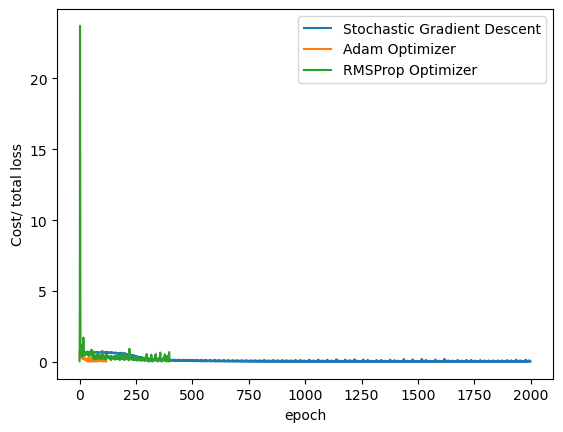

In [15]:
loss_SGD = loss_history["SGD"]
loss_Adam = loss_history["Adam"]
loss_rmsprop = loss_history["RMSProp"]


plt.plot(loss_SGD, label = "Stochastic Gradient Descent")
plt.plot(loss_Adam, label = "Adam Optimizer")
plt.plot(loss_rmsprop, label = 'RMSProp Optimizer')
plt.xlabel('epoch')
plt.ylabel('Cost/ total loss')
plt.legend()
plt.show()

## А теперь решите многоклассовую проблему

Продемонстрируйте свои знания - решите более сложную проблему
Попробуйте разные инициализации, методы оптимизации и кол-во нейронов.

Найдите лучшие параметры через KFold

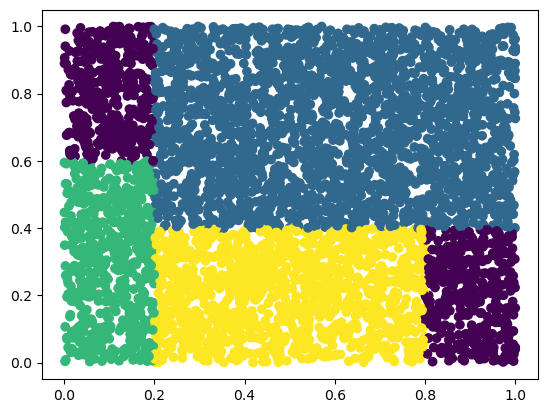

In [16]:
points = torch.rand(5000,2)
target = []
for p in points:
    if p[0]>0.2 and p[1]>0.4:
        target.append(1)
    elif p[0]<0.2 and p[1]<0.6:
        target.append(2)
    elif p[0]>0.2 and p[0]<0.8 and p[1] < 0.5:
        target.append(3)
    else:
        target.append(0)
        
target = torch.FloatTensor(target)
data = torch.as_tensor(np.column_stack((points,target)))

train = data[:800]
valid = data[800:900]
test = data[900:]

plt.scatter(data[:,0],data[:,1],c = data[:,2])
plt.show()

In [34]:
class AdvancedModel(nn.Module): 
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 36)
        nn.init.xavier_normal_(self.layer1.weight)
        nn.init.zeros_(self.layer1.bias)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(36, 36)
        nn.init.xavier_normal_(self.layer2.weight)
        nn.init.zeros_(self.layer2.bias)
        self.act2 = nn.LeakyReLU()
        self.layer3 = nn.Linear(36, 4)
        nn.init.xavier_normal_(self.layer3.weight)
        nn.init.zeros_(self.layer3.bias)
                        
    def forward(self, X):
        X = self.act1(self.layer1(X))
        X = self.act2(self.layer2(X))
        return X 

In [35]:
def train_model(model, loss_function, opt, 
          n_epochs, batch_size, lr,
          train, valid):
    #split dataset to target and dependenceye n
    X_train, y_train = train[:, :2],  train[:, 2].long()
    X_val, y_val = valid[:, :2], valid[:, 2].long()
    
    #convert valid dataset to tensor
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size)
    
    #convert dataset to tensor
    dataset_val = TensorDataset(X_val, y_val)
    loader_val = DataLoader(dataset_val, batch_size=batch_size)
    
    
    batch_start = torch.arange(0, len(X_train), batch_size)
    opt = opt(model.parameters(), lr=lr)
    
    # Hold the best model
    best_acc = - np.inf   # init to negative infinity
    total_correct = 0
    total_instances = 0
    best_weights = None
    loss_history = [] #took from seminar-3
    valid_loss_history = [] #history of losess
    
    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(loader, unit="batch", mininterval=0, disable=False) as bar:
            bar.set_description(f"Epoch {epoch}")
            for X_train, y_train in bar:

                y_train = y_train.type(torch.LongTensor)  
                
                # forward
                y_pred = model(X_train)
                
                loss = loss_function(y_pred, y_train)
                loss_history.append(loss.item())
                
                # backward pass
                opt.zero_grad() # makes gradients equal zero
                loss.backward() # backpropagation
                
                # update weights
                opt.step() # update model parametres

                #collect stats
                best_predictions = sum(torch.argmax(y_pred, dim=1) == y_train).item()
                total_correct = total_correct + best_predictions
                total_instances = total_instances + len(X_train)
                

                acc = round(total_correct/total_instances, 3)
                bar.set_postfix(
                    loss=float(loss),
                    acc=float(acc)
                )
                
                
            
            for X_valid, y_valid in loader_val:

                y_valid = y_valid.type(torch.LongTensor)
                y_valid_pred = model(X_valid)

                valid_loss = loss_function(y_valid_pred, y_valid)
                valid_loss_history.append(valid_loss.item())
                
            
        model.eval()
        y_pred = model(X_val)

        
        acc = (torch.argmax(y_pred, dim=1) == y_val).float().mean()
        acc = float(acc)
        
        if acc > best_acc:
            best_acc = acc
            best_weights = copy.deepcopy(model.state_dict())
        
    
    
    model.load_state_dict(best_weights)
    
    return loss_history, best_acc, valid_loss_history

In [36]:
loss_history, best_acc, valid_loss_history = train_model(AdvancedModel(), nn.CrossEntropyLoss(), torch.optim.Adam, 
          100, 30, 0.01,
          train, valid)
print(best_acc)

Epoch 99: 100%|███████████████████████████████████████████████| 6/6 [00:00<00:00, 182.00batch/s, acc=0.875, loss=0.074]

1.0


In [37]:
print('Минимальная ошибка на тесте:', round(min(loss_history), 3), 'Минимальная ошибка на валидации:', round(min(valid_loss_history), 3))

Минимальная ошибка на тесте: 0.006 Минимальная ошибка на валидации: 0.005


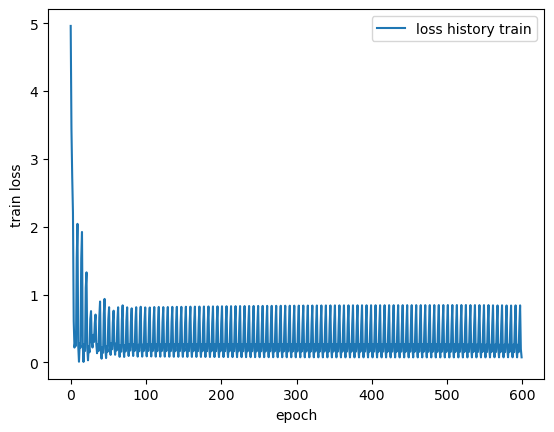

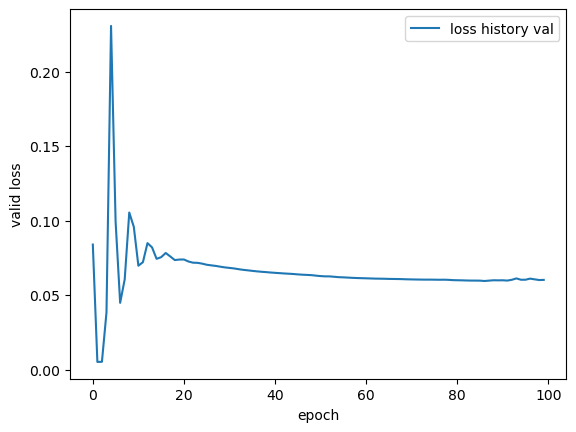

In [38]:
plt.plot(loss_history, label = "loss history train")
plt.xlabel('epoch')
plt.ylabel('train loss')
plt.legend()
plt.show()

plt.plot(valid_loss_history, label = "loss history val")
plt.xlabel('epoch')
plt.ylabel('valid loss')
plt.legend()
plt.show()

## (Почти) Боевая задача
 
Перед вами датасет с классификацией алкоголя. Продемонстрируйте свои знания и решите задачу многоклассовой классификации

In [22]:
df = sklearn.datasets.load_wine(as_frame=True)
df = df.frame
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [23]:
target = torch.FloatTensor(list(df.target))
tensor = torch.tensor(df.values, dtype=torch.float)
data = torch.as_tensor(np.column_stack((tensor,target)))

train = data[:158]
valid = data[158:168]
test = data[168:]

In [24]:
class WineModel(nn.Module): 
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(13, 36)
        nn.init.xavier_normal_(self.layer1.weight)
        nn.init.zeros_(self.layer1.bias)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(36, 36)
        nn.init.xavier_normal_(self.layer2.weight)
        nn.init.zeros_(self.layer2.bias)
        self.act2 = nn.LeakyReLU()
        self.layer3 = nn.Linear(36, 3)
        nn.init.xavier_normal_(self.layer3.weight)
        nn.init.zeros_(self.layer3.bias)

                        
    def forward(self, X):
        X = self.act1(self.layer1(X))
        X = self.act2(self.layer2(X))
        return X 

In [25]:
def train_model(model, loss_function, opt, 
          n_epochs, batch_size, lr,
          train, valid):
    #split dataset to target and dependenceye n
    X_train, y_train = train[:, :13],  train[:, 13].long()
    X_val, y_val = valid[:, :13], valid[:, 13].long()
    
    #convert valid dataset to tensor
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size)
    
    #convert dataset to tensor
    dataset_val = TensorDataset(X_val, y_val)
    loader_val = DataLoader(dataset_val, batch_size=batch_size)
    
    
    batch_start = torch.arange(0, len(X_train), batch_size)
    opt = opt(model.parameters(), lr=lr)
    
    # Hold the best model
    best_acc = - np.inf   # init to negative infinity
    total_correct = 0
    total_instances = 0
    best_weights = None
    loss_history = [] #took from seminar-3
    valid_loss_history = [] #history of losess
    
    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(loader, unit="batch", mininterval=0, disable=False) as bar:
            bar.set_description(f"Epoch {epoch}")
            for X_train, y_train in bar:

                y_train = y_train.type(torch.LongTensor)  
                
                # forward
                y_pred = model(X_train)
                
                loss = loss_function(y_pred, y_train)
                loss_history.append(loss.item())
                
                # backward pass
                opt.zero_grad() # makes gradients equal zero
                loss.backward() # backpropagation
                
                # update weights
                opt.step() # update model parametres

                #collect stats
                best_predictions = sum(torch.argmax(y_pred, dim=1) == y_train).item()
                total_correct = total_correct + best_predictions
                total_instances = total_instances + len(X_train)
                

                acc = round(total_correct/total_instances, 3)
                bar.set_postfix(
                    loss=float(loss),
                    acc=float(acc)
                )
                
                
            
            for X_valid, y_valid in loader_val:

                y_valid = y_valid.type(torch.LongTensor)
                y_valid_pred = model(X_valid)

                valid_loss = loss_function(y_valid_pred, y_valid)
                valid_loss_history.append(valid_loss.item())
                
            
        model.eval()
        y_pred = model(X_val)

        
        acc = (torch.argmax(y_pred, dim=1) == y_val).float().mean()
        acc = float(acc)
        
        if acc > best_acc:
            best_acc = acc
            best_weights = copy.deepcopy(model.state_dict())
        
    
    
    model.load_state_dict(best_weights)
    
    return loss_history, best_acc, valid_loss_history

In [26]:

loss_history, best_acc, valid_loss_history = train_model(WineModel(), nn.CrossEntropyLoss(), torch.optim.Adam, 
          400, 30, 0.01,
          train, valid)
print(best_acc)

Epoch 399: 100%|███████████████████████████████████████████| 6/6 [00:00<00:00, 146.49batch/s, acc=0.856, loss=0.000647]

1.0


In [27]:
print('Минимальная ошибка на тесте:', round(min(loss_history), 3), 'Минимальная ошибка на валидации:', round(min(valid_loss_history), 3))

Минимальная ошибка на тесте: 0.0 Минимальная ошибка на валидации: 0.0


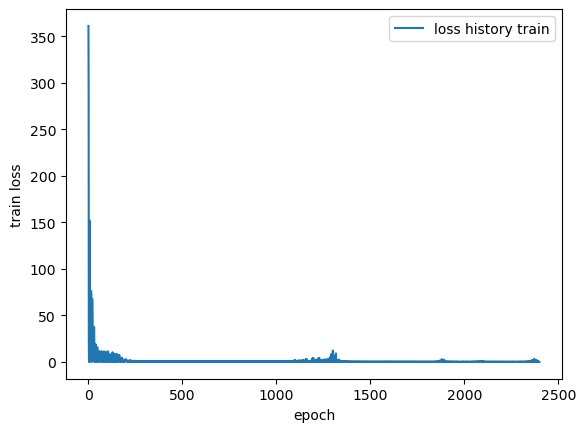

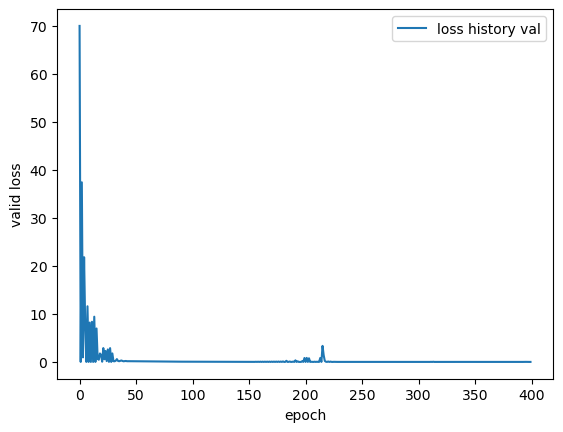

In [28]:
plt.plot(loss_history, label = "loss history train")
plt.xlabel('epoch')
plt.ylabel('train loss')
plt.legend()
plt.show()

plt.plot(valid_loss_history, label = "loss history val")
plt.xlabel('epoch')
plt.ylabel('valid loss')
plt.legend()
plt.show()